In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

### 1. PERSIAPAN DATASET DAN TABEL AWAL

In [68]:
data = {
    "Pesan_Teks": [
        "Kamu emang egois, mending putus aja kalau kamu terus lari dari masalah!",
        "Aku butuh waktu sendiri sebentar untuk tenang, nanti aku hubungi lagi ya.",
        "Gak usah sok peduli, kamu emang dari dulu ga pernah ngerti perasaanku!",
        "Bisa kita luangin waktu 10 menit malam ini buat bahas ini? Aku merasa cemas.",
        "Terserah, males ngomong sama kamu. Blokir aja sekalian.",
        "Maaf ya, aku lagi overwhelm, aku bukan bermaksud menghindar dari kamu.",
        "Kalau kamu gak bales chat aku sekarang, jangan harap bisa ketemu aku lagi!",
        "Aku hargai kamu butuh space, kabari aku kalau kamu udah siap ngobrol ya.",
        "Kamu terlalu clingy dan menuntut, aku muak denger keluhanmu terus.",
        "Aku sayang sama kamu, tapi cara kita berantem ini bikin kita capek. Mari perbaiki."
    ],
    "Label_Aktual": [1, 0, 1, 0, 1, 0, 1, 0, 1, 0], # 1=Toxic, 0=Non-Toxic
    "Gaya_Kelekatan": [
        "Anxious threat (Toxic)", 
        "Avoidant secure boundary (Sehat)", 
        "Defensive attack (Toxic)", 
        "Anxious secure expression (Sehat)", 
        "Avoidant stonewalling (Toxic)", 
        "Avoidant healthy reflection (Sehat)", 
        "Anxious manipulation (Toxic)", 
        "Anxious reassurance (Sehat)", 
        "Avoidant contempt (Toxic)", 
        "Healthy assessment (Sehat)"
    ]
}

df = pd.DataFrame(data)

print("                      TABEL DATA DAN LABEL AWAL                          ")
print(df[["Pesan_Teks", "Label_Aktual", "Gaya_Kelekatan"]].to_string(index=True))

                      TABEL DATA DAN LABEL AWAL                          
                                                                           Pesan_Teks  Label_Aktual                       Gaya_Kelekatan
0             Kamu emang egois, mending putus aja kalau kamu terus lari dari masalah!             1               Anxious threat (Toxic)
1           Aku butuh waktu sendiri sebentar untuk tenang, nanti aku hubungi lagi ya.             0     Avoidant secure boundary (Sehat)
2              Gak usah sok peduli, kamu emang dari dulu ga pernah ngerti perasaanku!             1             Defensive attack (Toxic)
3        Bisa kita luangin waktu 10 menit malam ini buat bahas ini? Aku merasa cemas.             0    Anxious secure expression (Sehat)
4                             Terserah, males ngomong sama kamu. Blokir aja sekalian.             1        Avoidant stonewalling (Toxic)
5              Maaf ya, aku lagi overwhelm, aku bukan bermaksud menghindar dari kamu.             0  Avo

### 2. Ekstraksi Fitur Teks (Mengubah kata menjadi angka)

In [69]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["Pesan_Teks"])
y = df["Label_Aktual"]

### 3. Latih Model Logistic Regression

In [70]:
model = LogisticRegression(random_state=42)
model.fit(X, y) # Memaksimalkan likelihood berdasarkan data latih

LogisticRegression(random_state=42)

### 4. PREDIKSI DAN PROBABILITAS (SIGMOID)

In [71]:
prediksi_kelas = model.predict(X)
probabilitas = model.predict_proba(X)

# Memasukkan hasil ke dalam DataFrame agar rapi
df["Prediksi_Model"] = prediksi_kelas
df["Peluang_Toxic (%)"] = np.round(probabilitas[:, 1] * 100, 1)

print("               TABEL HASIL PREDIKSI (DENGAN PROBABILITAS)                ")

# Menampilkan kolom-kolom inti dari hasil prediksi
print(df[["Pesan_Teks", "Label_Aktual", "Prediksi_Model", "Peluang_Toxic (%)"]].to_string(index=True))

               TABEL HASIL PREDIKSI (DENGAN PROBABILITAS)                
                                                                           Pesan_Teks  Label_Aktual  Prediksi_Model  Peluang_Toxic (%)
0             Kamu emang egois, mending putus aja kalau kamu terus lari dari masalah!             1               1               91.0
1           Aku butuh waktu sendiri sebentar untuk tenang, nanti aku hubungi lagi ya.             0               0               11.0
2              Gak usah sok peduli, kamu emang dari dulu ga pernah ngerti perasaanku!             1               1               90.0
3        Bisa kita luangin waktu 10 menit malam ini buat bahas ini? Aku merasa cemas.             0               0               11.6
4                             Terserah, males ngomong sama kamu. Blokir aja sekalian.             1               1               86.0
5              Maaf ya, aku lagi overwhelm, aku bukan bermaksud menghindar dari kamu.             0               0 

### 5. VISUALISASI DIAGRAM & GRAFIK

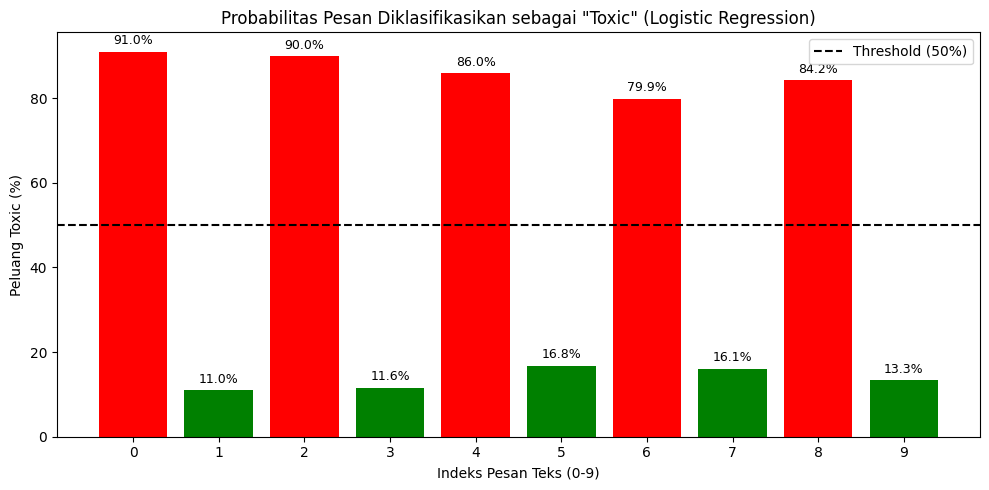

In [72]:
# A. Bar Chart: Visualisasi Peluang Toxic per Kalimat
plt.figure(figsize=(10, 5))
warna = ['red' if pred == 1 else 'green' for pred in df['Prediksi_Model']]
bars = plt.bar(df.index, df['Peluang_Toxic (%)'], color=warna)
plt.axhline(y=50, color='black', linestyle='--', label='Threshold (50%)')

# Menambahkan angka persentase di atas setiap bar grafik
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval}%', ha='center', va='bottom', fontsize=9)

plt.title('Probabilitas Pesan Diklasifikasikan sebagai "Toxic" (Logistic Regression)')
plt.xlabel('Indeks Pesan Teks (0-9)')
plt.ylabel('Peluang Toxic (%)')
plt.xticks(df.index)
plt.legend()
plt.tight_layout()
plt.show()

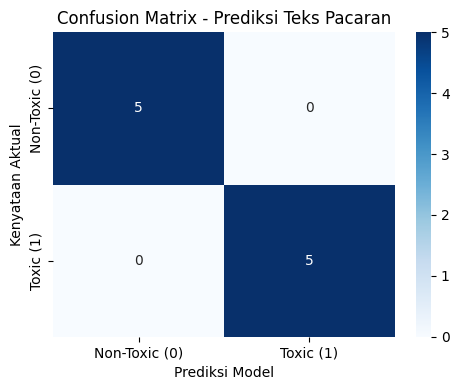

In [73]:
# B. Confusion Matrix (Evaluasi Prediksi)
cm = confusion_matrix(y, prediksi_kelas)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Toxic (0)', 'Toxic (1)'], 
            yticklabels=['Non-Toxic (0)', 'Toxic (1)'])
plt.title('Confusion Matrix - Prediksi Teks Pacaran')
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan Aktual')
plt.tight_layout()
plt.show()